In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp, quad
from scipy.linalg import solve_banded

plt.rcParams["figure.figsize"] = (8, 4.5)


# Задание 1

Решить задачу

$$
y^\prime\prime + (1-4x)y^\prime + 8y = 5, 0 < x < 1 \\ 
y^\prime (0) - y(0) = 0, y(1) = 0
$$

Воспользуемся методом вариации постоянной. Сначала решим однородное уравнение:
$$
y'' + (1-4x)y' + 8y = 0
$$

Поищем решение в виде $y_1 = ax^2 + bx + c$. Подставляя и группируя члены приходим к
$$
(-8a + 8a)x^2 + (2a-4b+8b)x + 2a + b + 8c = 0
$$

откуда, положив $b=-1$, получим $a = 2$ и $c = -\frac{3}{8}$

Теперь запишем метод вариации постоянной:

\begin{cases}
C_1^\prime y_1 + C_2^\prime y_2 = 0 \\
C_1^\prime y_1^\prime + C_2^\prime y_2^\prime = 5
\end{cases}

Найдем Вронскиан:
$$
W^\prime = -(1 - 4x)W \Rightarrow W = Ce^{2x^2 - x}
$$

Тогда
$$
y_2 = y_1 \int \frac{e^{2x^2 - x}}{y_1^2}\,dx
$$

Заметим, что $y_1 = 2x^2 - x - \tfrac{3}{8}$ обращается в нуль при $x = \tfrac{3}{4} \in (0, 1)$ и соответственно интеграл не сходится. Тогда т.к. мы ищем ограниченное решение возьмем $C_2 = 0$.

Частное решение неоднородного уравнения очевидно $y = \tfrac{5}{8}$.

Собирая все вместе:
$$
y = c_1\!\left(2x^2 - x - \frac{3}{8}\right) + \frac{5}{8}
$$

Пользуясь краевым условием $y(1) = 0$:
$$
 c_1 \cdot \tfrac{5}{8} = -\tfrac{5}{8} \implies c_1 = -1
$$

Таким образом общее решение
$$
y(x) = -2x^2 + x + 1
$$

# Задание 2

Решить краевую задачу методом дифференциальной прогонки:
$$
y'' = -y + x \cos x, \quad x \in \left[0,\, \frac{\pi}{2}\right]
$$
$$
y'(0) = 3y(0) + 2, \quad y'\!\left(\tfrac{\pi}{2}\right) = -5y\!\left(\tfrac{\pi}{2}\right) + 2
$$

Точное решение: $y = -0.73 \cos x - 0.441 \sin x + \tfrac{1}{4}(x^2 \sin x + x \cos x)$.

Метод дифференциальной прогонки состоит из прямой прогонки (нахождение $\alpha$ и $\beta$) и обратной прогонки (нахождение $y$).

Ищем решение в виде $y'(x) = \alpha(x)\,y(x) + \beta(x)$. Дифференцируя:
$$
y'' = \alpha' y + \alpha y' + \beta' = (\alpha' + \alpha^2)\,y + \alpha\beta + \beta'
$$

Уравнение $y'' + y = x\cos x$ даёт $(\alpha' + \alpha^2 + 1)\,y + (\beta' + \alpha\beta) = x\cos x$. Разделяя:
$$
\alpha' + \alpha^2 + 1 = 0, \qquad \beta' + \alpha\beta = x\cos x
$$

Начальные условия из левого ГУ $y'(0) = 3y(0) + 2$: так как $y'(0) = \alpha(0)\,y(0) + \beta(0)$, полагаем $\alpha(0) = 3$, $\beta(0) = 2$.

**Задача Коши 1: уравнение для $\alpha$.**

$$
\alpha' = -(1 + \alpha^2), \quad \alpha(0) = 3
$$

Разделяя переменные: $\dfrac{d\alpha}{1 + \alpha^2} = -dx$, откуда $\arctan\alpha = \arctan 3 - x$.

$$
\alpha(x) = \tan(\arctan 3 - x) = \frac{3\cos x - \sin x}{\cos x + 3\sin x}
$$

Проверим: $\alpha(0) = 3/1 = 3$, $\;\alpha(\pi/2) = (0 - 1)/(0 + 3) = -1/3$. Знаменатель $\cos x + 3\sin x > 0$ на $[0, \pi/2]$, особенностей нет.

**Задача Коши 2: уравнение для $\beta$.**

$$
\beta' + \alpha(x)\,\beta = x\cos x, \quad \beta(0) = 2
$$

Интегрирующий множитель: $\mu(x) = \exp\!\left(\int_0^x \alpha(t)\,dt\right)$. Заметим, что $(\cos x + 3\sin x)' = -\sin x + 3\cos x = 3\cos x - \sin x$, что совпадает с числителем $\alpha$. Поэтому $\alpha = \mu'/\mu$ с $\mu(x) = \cos x + 3\sin x$.

Решение:
$$
\beta(x) = \frac{1}{\cos x + 3\sin x}\left[2 + \int_0^x t\cos t\,(\cos t + 3\sin t)\,dt\right]
$$

Значение $\beta(\pi/2)$ вычислим численно.

**Определение $y(\pi/2)$ из правого ГУ.**

На правой границе $y' = \alpha y + \beta$ и $y' = -5y + 2$, откуда:
$$
(\alpha(\pi/2) + 5)\,y(\pi/2) = 2 - \beta(\pi/2) \implies y(\pi/2) = \frac{3\,(2 - \beta(\pi/2))}{14}
$$

**Задача Коши 3: обратная прогонка для $v \equiv y$.**

$$
v' = \alpha(x)\,v + \beta(x), \quad v(\pi/2) = y(\pi/2)
$$

Решаем от $x = \pi/2$ к $x = 0$, получая $y(x)$ на всём отрезке.

In [2]:
xb = np.pi / 2

def alpha_f(x):
    return (3*np.cos(x) - np.sin(x)) / (np.cos(x) + 3*np.sin(x))

def forward(x, y):
    al, be = y
    return [-(1 + al**2), x*np.cos(x) - al*be]

sol_fwd = solve_ivp(forward, [0, xb], [3.0, 2.0], dense_output=True, rtol=1e-12, atol=1e-13)
al_b, be_b = sol_fwd.y[:, -1]
y_b = (2 - be_b) / (al_b + 5)
dy_b = -5*y_b + 2
print(f"alpha(pi/2) = {al_b:.6f}")
print(f"beta(pi/2) = {be_b:.6f}")
print(f"y(pi/2) = {y_b:.6f}")
print(f"y'(pi/2) = {dy_b:.6f}")

def backward(x, v):
    al, be = sol_fwd.sol(x)
    return [al*v[0] + be]
sol_back = solve_ivp(backward, [xb, 0], [y_b], dense_output=True, rtol=1e-12, atol=1e-13)
x2 = np.linspace(0, xb, 300)
y2_num = sol_back.sol(x2)[0]
y2_ex = -0.73*np.cos(x2) - 0.441*np.sin(x2) + 0.25*(x2**2*np.sin(x2) + x2*np.cos(x2))
print(f"\nmax |y_num - y_exact| = {np.max(np.abs(y2_num - y2_ex)):.4e}")


alpha(pi/2) = -0.333333
beta(pi/2) = 1.181649
y(pi/2) = 0.175361
y'(pi/2) = 1.123196

max |y_num - y_exact| = 6.9712e-04


# Задание 3

Решить нелинейное уравнение Пуассона:
$$
\phi''(x) = e^{\phi(x)} - n(x), \quad n(x) = 1 + e^{-3(x-5)^2}
$$
в области $0 \le x \le 10$ с граничными условиями $\phi(0) = \phi(10) = 0$.

Пользоваться будем методом стрельбы, сходясь по Ньютону:

Решаем задачу Коши с начальными условиями $\phi(0) = 0$, $\phi'(0) = s$ и подбираем $s$ так, чтобы $\phi(10; s) = 0$.

Для нахождения $s$ применяем метод Ньютона. Обозначим $\psi = \partial\phi / \partial s$. Дифференцируя исходное уравнение по $s$, получаем вариационное уравнение:
$$
\psi'' = e^{\phi} \psi, \quad \psi(0) = 0, \quad \psi'(0) = 1
$$

Решаем совместную систему на $(\phi, \phi', \psi, \psi')$ и выполняем итерации:
$$
s \leftarrow s - \frac{\phi(10; s)}{\psi(10; s)}
$$


In [3]:
def n_func(x):
    return 1.0 + np.exp(-3.0 * (x - 5.0)**2)

def ode_aug(x, y):
    phi, dphi, psi, dpsi = y
    ep = np.exp(phi)
    return [dphi, ep - n_func(x), dpsi, ep * psi]

def shoot(s):
    sol = solve_ivp(ode_aug, [0, 10], [0.0, s, 0.0, 1.0],
                    rtol=1e-12, atol=1e-13, max_step=0.5)
    if sol.t[-1] < 9.99 or not np.all(np.isfinite(sol.y[:, -1])):
        return 1e10, 1.0
    return sol.y[0, -1], sol.y[2, -1]

# Костыльная бисекция, иначе оно взрывается
s_lo, s_hi = -1.0, 1.0
for _ in range(60):
    s_mid = (s_lo + s_hi) / 2
    F_mid, _ = shoot(s_mid)
    if F_mid < 0:
        s_lo = s_mid
    else:
        s_hi = s_mid

s = (s_lo + s_hi) / 2


for it in range(20):
    F_val, dF_val = shoot(s)
    if abs(F_val) < 1e-10:
        print(f"Ньютон сошёлся за {it + 1} итераций, s = {s:.10f}")
        break
    s -= F_val / dF_val

sol3 = solve_ivp(ode_aug, [0, 10], [0.0, s, 0.0, 1.0],
                 rtol=1e-12, atol=1e-13, dense_output=True)

def bvp_rhs(x, y):
    return np.vstack([y[1], np.exp(y[0]) - n_func(x)])
def bvp_bc(ya, yb):
    return [ya[0], yb[0]]
x_bvp = np.linspace(0, 10, 300)
y_guess = sol3.sol(x_bvp)[:2]
sol_bvp = solve_bvp(bvp_rhs, bvp_bc, x_bvp, y_guess, tol=1e-8)
print(f"solve_bvp сошлось: {sol_bvp.success}")


Ньютон сошёлся за 1 итераций, s = 0.0065175898
solve_bvp сошлось: True


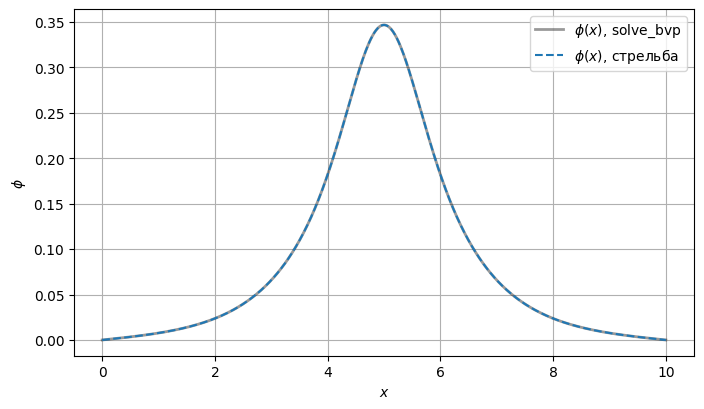

max |стрельба - solve_bvp| = 8.8973e-11


In [4]:
x_plt = np.linspace(0, 10, 600)
phi_plt = sol3.sol(x_plt)[0]
phi_ref = sol_bvp.sol(x_plt)[0]

fig, ax = plt.subplots()
ax.plot(x_plt, phi_ref, "k-", lw=2, alpha=0.4, label=r"$\phi(x)$, solve_bvp")
ax.plot(x_plt, phi_plt, "--", label=r"$\phi(x)$, стрельба")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\phi$")
ax.legend()
ax.grid()
plt.show()

print(f"max |стрельба - solve_bvp| = {np.max(np.abs(phi_plt - phi_ref)):.4e}")


## Задание 4

Возьмем сетку с шагом $h = 10/N$:
$$F_i = \phi_{i-1} - 2\phi_i + \phi_{i+1} - h^2(e^{\phi_i} - n_i) = 0.$$

Получим трёхдиагональный Якобиан: $J_{ii} = -2 - h^2 e^{\phi_i}$, $J_{i,i\pm1} = 1$.


In [5]:
N = 500
h = 10.0 / N
x4 = np.linspace(0, 10, N + 1)
n4 = n_func(x4)

phi4 = np.zeros(N - 1)

n_iter4 = 0
for it in range(50):
    phi_full = np.concatenate([[0.0], phi4, [0.0]])
    F = (phi_full[:-2] - 2*phi_full[1:-1] + phi_full[2:]) - h**2 * (np.exp(phi4) - n4[1:-1])
    norm_F = np.max(np.abs(F))
    diag = -2.0 - h**2 * np.exp(phi4)
    off  = np.ones(N - 2)
    ab = np.zeros((3, N - 1))
    ab[0, 1:]  = off
    ab[1, :]   = diag
    ab[2, :-1] = off
    delta = solve_banded((1, 1), ab, -F)
    phi4 += delta
    n_iter4 = it + 1
    if norm_F < 1e-10:
        break

print(f"Ньютон на сетке сошёлся за {n_iter4} итераций")
phi_full4 = np.concatenate([[0.0], phi4, [0.0]])


Ньютон на сетке сошёлся за 4 итераций


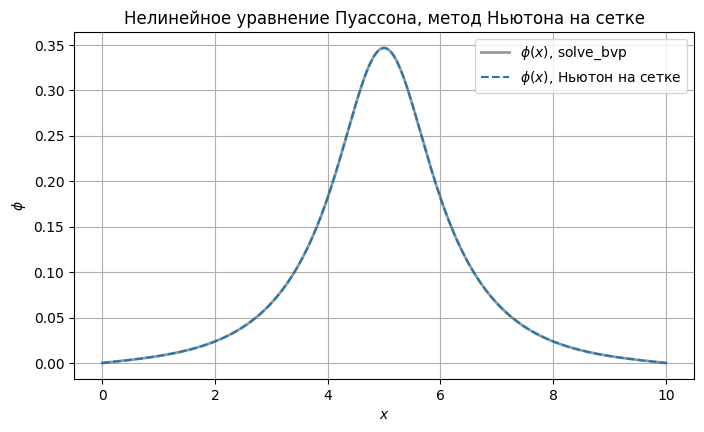

max |сетка - solve_bvp| = 1.4067e-05


In [6]:
phi_ref4 = sol_bvp.sol(x4)[0]

fig, ax = plt.subplots()
ax.plot(x4, phi_ref4, "k-", lw=2, alpha=0.4, label=r"$\phi(x)$, solve_bvp")
ax.plot(x4, phi_full4, "--", label=r"$\phi(x)$, Ньютон на сетке")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\phi$")
ax.set_title("Нелинейное уравнение Пуассона, метод Ньютона на сетке")
ax.legend()
ax.grid()
plt.show()

print(f"max |сетка - solve_bvp| = {np.max(np.abs(phi_full4 - phi_ref4)):.4e}")


## Задание 5

$$\ddot{x} = 2x^3, \quad x(0) = \tfrac{1}{2},\quad x(1) = \tfrac{1}{3}, \qquad x^*(t) = \frac{1}{2+t}.$$

Разложение: $x_n(t) = x_0(t) + \sum_{k=1}^n a_k\,\varphi_k(t)$,  
$x_0(t) = \tfrac12 - \tfrac{t}{6}$,  $\varphi_k(t) = t^k(1-t)$.

Условия Галёркина: $\displaystyle\int_0^1 (\ddot{x}_n - 2x_n^3)\,\varphi_j\,dt = 0$.  
Якобиан: $J_{jk} = \displaystyle\int_0^1 (\ddot{\varphi}_k - 6x_n^2\,\varphi_k)\,\varphi_j\,dt$.


In [7]:
def x0(t):
    return 0.5 - t / 6.0

def phi_k(t, k):
    return t**k * (1.0 - t)

def ddphi_k(t, k):
    if k == 1:
        return -2.0
    return k*(k - 1)*t**(k - 2) - k*(k + 1)*t**(k - 1)

def x_n(t, a):
    return x0(t) + sum(a[k-1] * phi_k(t, k) for k in range(1, len(a) + 1))

def ddx_n(t, a):
    return sum(a[k-1] * ddphi_k(t, k) for k in range(1, len(a) + 1))

def F_galerkin(a):
    n = len(a)
    F = np.empty(n)
    for j in range(1, n + 1):
        F[j-1], _ = quad(lambda t: (ddx_n(t, a) - 2*x_n(t, a)**3) * phi_k(t, j), 0, 1)
    return F

def J_galerkin(a):
    n = len(a)
    J = np.empty((n, n))
    for j in range(1, n + 1):
        for k in range(1, n + 1):
            J[j-1, k-1], _ = quad(
                lambda t, k=k: (ddphi_k(t, k) - 6*x_n(t, a)**2 * phi_k(t, k)) * phi_k(t, j),
                0, 1)
    return J

def newton_galerkin(n_basis, tol=1e-12):
    a = np.zeros(n_basis)
    for it in range(30):
        F = F_galerkin(a)
        if np.linalg.norm(F) < tol:
            break
        a -= np.linalg.solve(J_galerkin(a), F)
    return a

a1 = newton_galerkin(1)
a2 = newton_galerkin(2)


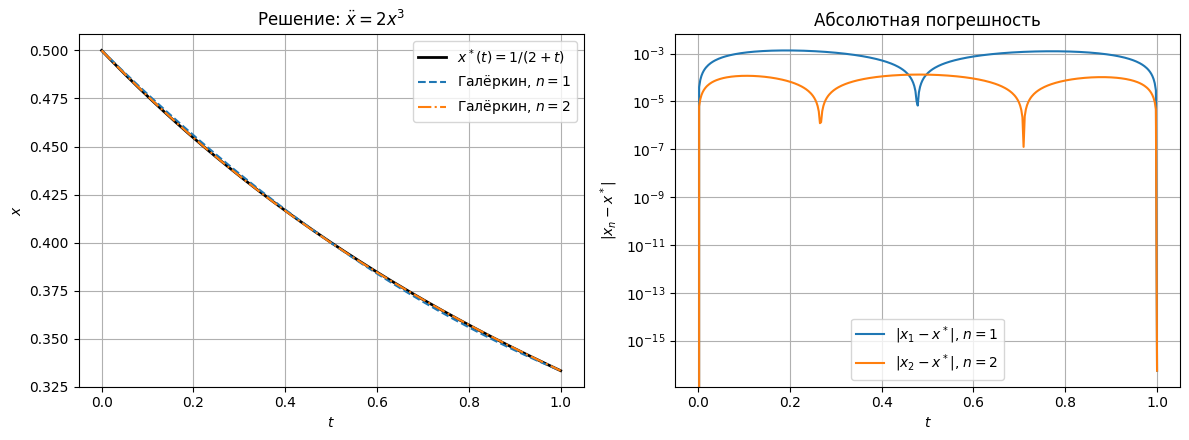

Относительная погрешность:
n=1: 2.720e-03
n=2: 2.668e-04


In [8]:
t_plt5 = np.linspace(0, 1, 400)
x_ex   = 1.0 / (2.0 + t_plt5)
x_a1   = np.array([x_n(t, a1) for t in t_plt5])
x_a2   = np.array([x_n(t, a2) for t in t_plt5])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(t_plt5, x_ex, "k-",  lw=2, label=r"$x^*(t)=1/(2+t)$")
ax1.plot(t_plt5, x_a1, "--",        label=r"Галёркин, $n=1$")
ax1.plot(t_plt5, x_a2, "-.",        label=r"Галёркин, $n=2$")
ax1.set_xlabel(r"$t$")
ax1.set_ylabel(r"$x$")
ax1.set_title(r"Решение: $\ddot{x}=2x^3$")
ax1.legend()
ax1.grid()

ax2.plot(t_plt5, np.abs(x_a1 - x_ex), label=r"$|x_1 - x^*|$, $n=1$")
ax2.plot(t_plt5, np.abs(x_a2 - x_ex), label=r"$|x_2 - x^*|$, $n=2$")
ax2.set_yscale("log")
ax2.set_xlabel(r"$t$")
ax2.set_ylabel(r"$|x_n - x^*|$")
ax2.set_title("Абсолютная погрешность")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

err1 = np.max(np.abs(x_a1 - x_ex)) / np.max(x_ex)
err2 = np.max(np.abs(x_a2 - x_ex)) / np.max(x_ex)
print(f"Относительная погрешность:")
print(f"n=1: {err1:.3e}")
print(f"n=2: {err2:.3e}")
